# BikeFlow 06 — Rolling Features / 历史窗口特征

## TL;DR

本实验在 05 的 HistGradientBoosting 模型、时间切分和 45 个基础特征上，分别加入短期、日、周 rolling 特征，并在**共同有效样本**上重新训练 V3 基线。**本次运行：Short Rolling 最佳，测试 MAE 360.09、RMSE 586.06、R² 0.977；相对 V3 基线 MAE 391.42 改善 8.01%。**五组完整指标和自动生成的结论见下文。所有主指标使用未经裁剪的预测。

**预测口径：**逐小时滚动的下一小时预测（one-step-ahead forecasting）。预测时刻 `t` 时，假定 `t-1` 的真实骑行需求已可获得；测试时段的历史真实需求可以进入后续时刻的 lag 和 rolling。天气字段沿用 05 的同小时历史观测值；实际部署应使用当时可获得的天气预报。

## 1. 目标、特征含义与关键假设

研究问题：在时间、天气、`lag_1`、`lag_24`、`lag_168` 已存在的条件下，过去一段时间的平均水平和波动程度能否进一步降低测试误差？只固定使用 `HistGradientBoostingRegressor`，不再比较模型家族。

| 特征 | 含义 | 例子 |
|---|---|---|
| Lag | 某一个**具体历史时刻**的值 | `lag_24` 是昨天这个小时的需求 |
| Rolling Mean | 一段**历史窗口的平均状态** | `rolling_mean_24` 是截至上一小时的过去 24 小时平均需求 |
| Rolling Std | 一段**历史窗口的波动程度** | `rolling_std_24` 衡量过去 24 小时需求变化是否剧烈 |

**防止目标泄漏：**若直接写 `demand.rolling(24).mean()`，窗口可能包含当前待预测的 `y_t`。这里先用 `demand.shift(1)`，再计算 rolling，因此预测 `t` 时最晚只能用 `t-1`，最早用 `t-window`。所有窗口要求完整的 `window` 个历史小时；不足时保留 `NaN`，建模前一次性取共同有效行。

**固定评估：**05 的测试期 `2024-10-19 18:00` 至 `2024-12-31 23:00`，共 1,757 小时。数据源为 `data/processed/bikeflow_2024.csv`。训练到测试的时间顺序不变。此处在同一测试集比较多个 rolling 方案，选中的最佳方案仍需要未来独立时段验证。

### 1.1 导入工具

**做什么：**导入表格、绘图、模型和评估工具。**为什么：**后续五组实验须共用同一套计算和显示口径。**输入：**本地 Python 环境。**输出：**可复用的库和统一图表样式。

In [1]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "font.size": 10,
    "axes.grid": False,
    "savefig.dpi": 130,
})
COLORS = {"Actual": "#242C33", "V3 Baseline": "#24567A", "Best Rolling": "#C66A32"}

## 2. 读取与检查原始小时序列

**做什么：**从项目中的处理后 CSV 读取全年 8,784 个连续钟表小时。**为什么：**lag 和 rolling 都要先在完整小时序列上生成；先删除夏令时特殊行会改变窗口的钟表小时位置。**输入：**`data/processed/bikeflow_2024.csv`。**输出：**按时间排序、无重复的 `data`。

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "processed" / "bikeflow_2024.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "bikeflow_2024.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError("请从 BikeFlow 项目根目录或 notebooks 目录运行")

data = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
data = data.sort_values("timestamp").reset_index(drop=True)
assert len(data) == 8784
assert not data["timestamp"].duplicated().any()
assert data["timestamp"].diff().iloc[1:].eq(pd.Timedelta(hours=1)).all()
assert data["ride_count"].notna().all()
print(f"来源：{DATA_PATH}")
print(f"原始小时：{len(data):,}；范围：{data['timestamp'].min()} 至 {data['timestamp'].max()}")
display(data[["timestamp", "ride_count"]].head(3))

来源：C:\Users\txy18\Desktop\BikeFlow\data\processed\bikeflow_2024.csv
原始小时：8,784；范围：2024-01-01 00:00:00 至 2024-12-31 23:00:00


,timestamp,ride_count
0,2024-01-01 00:00:00,1901
1,2024-01-01 01:00:00,2333
2,2024-01-01 02:00:00,1939


### 2.1 沿用 05 的建模行与固定切分

**做什么：**只从**目标建模行**排除两个夏令时特殊标签，再在删特征空值之前固定 80/20 时间边界。**为什么：**切分时间不能因不同窗口损失的起始行而移动。**输入：**完整小时序列。**输出：**8,782 个候选建模小时和 `2024-10-19 18:00` 测试起点。

春季 `02:00` 占位行、秋季 `01:00` 合并行仍留在完整历史序列中，可能影响附近的 rolling 统计；这与 05 的 lag 数据口径一致。切换附近的 168 行是 **168 个钟表标签**，不严格等于 168 个物理小时。

In [3]:
SPRING_GAP = pd.Timestamp("2024-03-10 02:00")
FALL_REPEAT = pd.Timestamp("2024-11-03 01:00")
spring_row = data.loc[data["timestamp"].eq(SPRING_GAP)]
fall_row = data.loc[data["timestamp"].eq(FALL_REPEAT)]
assert len(spring_row) == len(fall_row) == 1
assert spring_row["ride_count"].iloc[0] == 0
assert spring_row.drop(columns=["timestamp", "ride_count"]).isna().all(axis=None)

normal_hour_mask = ~data["timestamp"].isin([SPRING_GAP, FALL_REPEAT])
model_data = data.loc[normal_hour_mask].copy().reset_index(drop=True)
model_data["hour"] = model_data["timestamp"].dt.hour
model_data["day_of_week"] = model_data["timestamp"].dt.dayofweek
model_data["month"] = model_data["timestamp"].dt.month

split_index = int(len(model_data) * 0.8)
fixed_test_start = model_data["timestamp"].iloc[split_index]
assert len(model_data) == 8782 and split_index == 7025
assert fixed_test_start == pd.Timestamp("2024-10-19 18:00")
assert model_data["timestamp"].iloc[-1] == pd.Timestamp("2024-12-31 23:00")
print(f"建模候选行：{len(model_data):,}；原 80/20 切分索引：{split_index:,}")
print(f"固定测试起点：{fixed_test_start}")

建模候选行：8,782；原 80/20 切分索引：7,025
固定测试起点：2024-10-19 18:00:00


## 3. 构造 lag 与 rolling 特征

**做什么：**先在完整的 `data` 上生成三个 lag；对 `ride_count.shift(1)` 分别计算 3、6、24、168 小时的均值，以及 24、168 小时的标准差，然后映射到建模行。**为什么：**每个值都必须来自预测时刻以前，而且要与 05 的 lag 口径一致。**输入：**完整 `ride_count`。**输出：**九个历史需求特征，其中六个是本 Notebook 新研究的 rolling 特征。

标准差使用 pandas 的默认样本标准差（`ddof=1`）；24 和 168 个完整样本足够计算。下方同时检查缺失、非有限值及极端值范围。

In [4]:
lag_columns = ["lag_1", "lag_24", "lag_168"]
rolling_mean_columns = ["rolling_mean_3", "rolling_mean_6", "rolling_mean_24", "rolling_mean_168"]
rolling_std_columns = ["rolling_std_24", "rolling_std_168"]
rolling_columns = rolling_mean_columns + rolling_std_columns

data["lag_1"] = data["ride_count"].shift(1)
data["lag_24"] = data["ride_count"].shift(24)
data["lag_168"] = data["ride_count"].shift(168)

prior_demand = data["ride_count"].shift(1)
data["rolling_mean_3"] = prior_demand.rolling(window=3, min_periods=3).mean()
data["rolling_mean_6"] = prior_demand.rolling(window=6, min_periods=6).mean()
data["rolling_mean_24"] = prior_demand.rolling(window=24, min_periods=24).mean()
data["rolling_mean_168"] = prior_demand.rolling(window=168, min_periods=168).mean()
data["rolling_std_24"] = prior_demand.rolling(window=24, min_periods=24).std()
data["rolling_std_168"] = prior_demand.rolling(window=168, min_periods=168).std()

model_data[lag_columns + rolling_columns] = data.loc[
    normal_hour_mask, lag_columns + rolling_columns
].to_numpy()
assert np.isfinite(model_data[rolling_columns].dropna().to_numpy()).all()
assert (model_data[rolling_std_columns].dropna() >= 0).all(axis=None)

feature_quality = pd.DataFrame({
    "NaN (full series)": data[rolling_columns].isna().sum(),
    "Valid min": data[rolling_columns].min(),
    "Valid median": data[rolling_columns].median(),
    "Valid p99": data[rolling_columns].quantile(0.99),
    "Valid max": data[rolling_columns].max(),
})
display(feature_quality.round(1))
assert data["rolling_mean_168"].isna().sum() == 168
assert data["rolling_std_168"].isna().sum() == 168
print("168 小时窗口的前 168 行 NaN 来自历史不足；之后六列均为有限值。")

,NaN (full series),Valid min,Valid median,Valid p99,Valid max
rolling_mean_3,3,73.3,4371.7,15155.2,17447.3
rolling_mean_6,6,129.8,4477.3,13134.5,14554.3
rolling_mean_24,24,886.8,5370.1,7903.3,8374.9
rolling_mean_168,168,1510.3,5506.4,7576.4,7633.8
rolling_std_24,24,500.3,3808.9,5565.0,5743.3
rolling_std_168,168,1126.8,3997.6,5220.3,5255.2


168 小时窗口的前 168 行 NaN 来自历史不足；之后六列均为有限值。


### 3.1 核查每个 rolling 值的历史来源

**做什么：**对测试起点、普通测试小时、夏令时附近和最后测试小时，逐窗口手工重算，并列出最早与最晚来源时间；再故意改变当前及未来目标值，检查当前 rolling 是否不变。**为什么：**仅看到 `shift(1)` 还不够，实际数值和历史边界也应可核验。**输入：**完整原始需求和六列 rolling。**输出：**来源表与无当前／未来目标泄漏的断言。

In [5]:
audit_times = [
    pd.Timestamp("2024-01-08 00:00"),
    pd.Timestamp("2024-10-19 17:00"),
    fixed_test_start,
    pd.Timestamp("2024-10-20 08:00"),
    pd.Timestamp("2024-11-03 02:00"),
    pd.Timestamp("2024-12-31 23:00"),
]
rolling_spec = {
    "rolling_mean_3": (3, "mean"),
    "rolling_mean_6": (6, "mean"),
    "rolling_mean_24": (24, "mean"),
    "rolling_mean_168": (168, "mean"),
    "rolling_std_24": (24, "std"),
    "rolling_std_168": (168, "std"),
}
audit_rows = []
for prediction_time in audit_times:
    position = data.index[data["timestamp"].eq(prediction_time)][0]
    for feature, (window, statistic) in rolling_spec.items():
        source = data["ride_count"].iloc[position - window:position]
        source_times = data["timestamp"].iloc[position - window:position]
        assert len(source) == window
        assert source_times.iloc[-1] == prediction_time - pd.Timedelta(hours=1)
        assert (source_times < prediction_time).all()
        manual_value = source.mean() if statistic == "mean" else source.std(ddof=1)
        feature_value = data.loc[position, feature]
        assert np.isclose(manual_value, feature_value, rtol=1e-10, atol=1e-8)
        audit_rows.append({
            "Feature": feature, "Prediction time": prediction_time,
            "First source": source_times.iloc[0], "Last source": source_times.iloc[-1],
            "Manual": manual_value, "Feature value": feature_value,
        })

leakage_audit = pd.DataFrame(audit_rows)
audit_preview = leakage_audit.loc[leakage_audit["Prediction time"].eq(fixed_test_start)].copy()
audit_preview[["Manual", "Feature value"]] = audit_preview[["Manual", "Feature value"]].round(2)
display(audit_preview)

check_position = data.index[data["timestamp"].eq(pd.Timestamp("2024-10-20 08:00"))][0]
changed_demand = data["ride_count"].copy()
changed_demand.iloc[check_position:] += 1_000_000  # 只改变当前及未来目标
changed_prior = changed_demand.shift(1)
for feature, (window, statistic) in rolling_spec.items():
    changed_window = changed_prior.rolling(window=window, min_periods=window)
    changed_value = (changed_window.mean() if statistic == "mean" else changed_window.std()).iloc[check_position]
    assert np.isclose(changed_value, data.loc[check_position, feature], rtol=1e-10, atol=1e-8)
print(f"已核查 {len(leakage_audit)} 个窗口：最晚来源均为 t-1；改变 y_t 及未来值后，t 的六列 rolling 不变。")

,Feature,Prediction time,First source,Last source,Manual,Feature value
12,rolling_mean_3,2024-10-19 18:00:00,2024-10-19 15:00:00,2024-10-19 17:00:00,13472.00,13472.00
13,rolling_mean_6,2024-10-19 18:00:00,2024-10-19 12:00:00,2024-10-19 17:00:00,13372.00,13372.00
14,rolling_mean_24,2024-10-19 18:00:00,2024-10-18 18:00:00,2024-10-19 17:00:00,7259.96,7259.96
15,rolling_mean_168,2024-10-19 18:00:00,2024-10-12 18:00:00,2024-10-19 17:00:00,6440.28,6440.28
16,rolling_std_24,2024-10-19 18:00:00,2024-10-18 18:00:00,2024-10-19 17:00:00,4955.33,4955.33
17,rolling_std_168,2024-10-19 18:00:00,2024-10-12 18:00:00,2024-10-19 17:00:00,4453.65,4453.65


已核查 36 个窗口：最晚来源均为 t-1；改变 y_t 及未来值后，t 的六列 rolling 不变。


## 4. 固定全部实验的共同样本

**做什么：**要求三个 lag 和六个 rolling 在同一行都有效，再分别取固定边界前后的训练与测试行。**为什么：**短期、日、周方案若使用不同训练起点，MAE 差异不能只归于新增特征。**输入：**建模行及历史需求特征。**输出：**五个方案共用的 6,857 个训练小时和 1,757 个测试小时。

168 小时 rolling 的第一个有效位置恰好也是 `lag_168` 的第一个有效位置。因此本数据中共同样本**没有减少 05 基线的训练行数**；仍重新计算 V3 基线，保证同一运行环境和代码口径。

In [6]:
history_columns = lag_columns + rolling_columns
valid_history = model_data[history_columns].notna().all(axis=1)
train_mask = model_data["timestamp"] < fixed_test_start
test_mask = ~train_mask
train_rows = model_data.loc[train_mask & valid_history].copy()
test_rows = model_data.loc[test_mask & valid_history].copy()

assert len(train_rows) == 6857
assert len(test_rows) == 1757
assert train_rows["timestamp"].min() == pd.Timestamp("2024-01-08 00:00")
assert train_rows["timestamp"].max() == pd.Timestamp("2024-10-19 17:00")
assert test_rows["timestamp"].min() == fixed_test_start
assert test_rows["timestamp"].max() == pd.Timestamp("2024-12-31 23:00")
assert train_rows["timestamp"].max() < test_rows["timestamp"].min()
assert np.isfinite(train_rows[history_columns].to_numpy()).all()
assert np.isfinite(test_rows[history_columns].to_numpy()).all()

sample_counts = pd.DataFrame([
    {"Set": "05 HistGradientBoosting", "First hour": "2024-01-08 00:00", "Last hour": "2024-10-19 17:00", "Hours": 6857},
    {"Set": "06 common train", "First hour": train_rows["timestamp"].min(), "Last hour": train_rows["timestamp"].max(), "Hours": len(train_rows)},
    {"Set": "06 common test", "First hour": test_rows["timestamp"].min(), "Last hour": test_rows["timestamp"].max(), "Hours": len(test_rows)},
])
display(sample_counts)

,Set,First hour,Last hour,Hours
0,05 HistGradientBoosting,2024-01-08 00:00,2024-10-19 17:00,6857
1,06 common train,2024-01-08 00:00:00,2024-10-19 17:00:00,6857
2,06 common test,2024-10-19 18:00:00,2024-12-31 23:00:00,1757


### 4.1 复现 05 的 45 列基础矩阵

**做什么：**只根据训练期生成 hour、day_of_week、month 的 One-Hot 列，结合四个天气变量和三个 lag，再追加六个 rolling 候选列。**为什么：**05 的基线必须在相同特征顺序上重建；测试期不能决定训练特征列。**输入：**共同训练／测试行及时间类别。**输出：**完整候选特征矩阵和目标值。

训练只到 10 月，11、12 月没有单独的训练 dummy，这也是 05 的既有外推限制。所有天气值是同小时历史观测，不应在真实提前预测时当作已知量。

In [7]:
weather_features = [
    "temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"
]
categorical_time_features = ["hour", "day_of_week", "month"]
assert model_data[weather_features + ["ride_count"]].notna().all(axis=None)

time_train = model_data.loc[train_mask, categorical_time_features].copy()
time_test = model_data.loc[test_mask, categorical_time_features].copy()
for frame in (time_train, time_test):
    frame["hour"] = pd.Categorical(frame["hour"], categories=range(24))
    frame["day_of_week"] = pd.Categorical(frame["day_of_week"], categories=range(7))
    frame["month"] = pd.Categorical(frame["month"], categories=range(1, 13))

dummy_train = pd.get_dummies(time_train, drop_first=True, dtype=int)
dummy_test = pd.get_dummies(time_test, drop_first=True, dtype=int)
trained_dummy_columns = dummy_train.columns[dummy_train.any(axis=0)]
dummy_train = dummy_train[trained_dummy_columns]
dummy_test = dummy_test[trained_dummy_columns]
assert dummy_train.columns.equals(dummy_test.columns)

time_dummies = pd.concat([dummy_train, dummy_test]).sort_index()
candidate_columns = weather_features + lag_columns + rolling_columns
full_matrix = pd.concat([time_dummies, model_data[candidate_columns]], axis=1)
X_train_all = full_matrix.loc[train_rows.index].copy()
X_test_all = full_matrix.loc[test_rows.index].copy()
y_train = train_rows["ride_count"].copy()
y_test = test_rows["ride_count"].copy()
base_features = dummy_train.columns.tolist() + weather_features + lag_columns

assert len(dummy_train.columns) == 38 and len(base_features) == 45
assert X_train_all.index.equals(y_train.index) and X_test_all.index.equals(y_test.index)
assert X_train_all.notna().all(axis=None) and X_test_all.notna().all(axis=None)
assert np.isfinite(X_train_all.to_numpy()).all() and np.isfinite(X_test_all.to_numpy()).all()
print(f"基础特征：{len(base_features)} 列 = 38 时间 dummy + 4 天气 + 3 lag")
print(f"新增 rolling 候选：{', '.join(rolling_columns)}")

基础特征：45 列 = 38 时间 dummy + 4 天气 + 3 lag
新增 rolling 候选：rolling_mean_3, rolling_mean_6, rolling_mean_24, rolling_mean_168, rolling_std_24, rolling_std_168


## 5. 五组 Ablation Experiment

**做什么：**A 为 V3 基线，B/C/D 分别单独在基线上加短期／日／周 rolling，E 加六列全部 rolling。**为什么：**可以区分哪一类窗口有用，并检查全部加入是否反而增加冗余。**输入：**同一基础矩阵。**输出：**固定的特征方案和 05 完全相同的 HistGradientBoosting 参数。

In [8]:
feature_sets = {
    "A. V3 Baseline": base_features,
    "B. + Short Rolling": base_features + ["rolling_mean_3", "rolling_mean_6"],
    "C. + Daily Rolling": base_features + ["rolling_mean_24", "rolling_std_24"],
    "D. + Weekly Rolling": base_features + ["rolling_mean_168", "rolling_std_168"],
    "E. All Rolling Features": base_features + rolling_columns,
}
added_features = {
    "A. V3 Baseline": "None",
    "B. + Short Rolling": "rolling_mean_3, rolling_mean_6",
    "C. + Daily Rolling": "rolling_mean_24, rolling_std_24",
    "D. + Weekly Rolling": "rolling_mean_168, rolling_std_168",
    "E. All Rolling Features": "all 6 rolling features",
}
model_parameters = {
    "max_iter": 240,
    "learning_rate": 0.07,
    "max_leaf_nodes": 31,
    "min_samples_leaf": 25,
    "l2_regularization": 0.1,
    "early_stopping": False,
    "random_state": 42,
}
assert all(columns[:45] == base_features for columns in feature_sets.values())
display(pd.DataFrame([
    {"Model": name, "Features Added": added_features[name], "Total Features": len(columns)}
    for name, columns in feature_sets.items()
]))
display(pd.DataFrame(list(model_parameters.items()), columns=["Parameter", "Value"]))

,Model,Features Added,Total Features
0,A. V3 Baseline,None,45
1,B. + Short Rolling,"rolling_mean_3, rolling_mean_6",47
2,C. + Daily Rolling,"rolling_mean_24, rolling_std_24",47
3,D. + Weekly Rolling,"rolling_mean_168, rolling_std_168",47
4,E. All Rolling Features,all 6 rolling features,51


,Parameter,Value
0,max_iter,240
1,learning_rate,0.07
2,max_leaf_nodes,31
3,min_samples_leaf,25
4,l2_regularization,0.1
5,early_stopping,False
6,random_state,42


### 5.1 训练、预测和统一指标表

**做什么：**五组模型只在共同训练行上拟合；对同一 1,757 小时测试集计算 MAE、RMSE、R²、负预测数，并相对重新计算的 V3 基线求改善。**为什么：**除特征列之外，模型参数、数据行和评估代码都保持一致。**输入：**五组特征列、共同矩阵及真实需求。**输出：**按测试 MAE 升序排列的主结果表及各模型预测。

改善定义：`Baseline MAE − Model MAE`；正值是改善，负值是变差。百分比再除以基线 MAE。表中的预测没有进行零下裁剪。

In [9]:
fitted_models = {}
train_predictions = {}
test_predictions = {}
comparison_rows = []

for model_name, feature_columns in feature_sets.items():
    X_train = X_train_all[feature_columns]
    X_test = X_test_all[feature_columns]
    model = HistGradientBoostingRegressor(**model_parameters)
    model.fit(X_train, y_train)
    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)
    assert len(test_prediction) == len(y_test) and np.isfinite(test_prediction).all()
    fitted_models[model_name] = model
    train_predictions[model_name] = train_prediction
    test_predictions[model_name] = test_prediction
    comparison_rows.append({
        "Model": model_name,
        "Features Added": added_features[model_name],
        "Train Samples": len(X_train),
        "Test Samples": len(X_test),
        "MAE": mean_absolute_error(y_test, test_prediction),
        "RMSE": np.sqrt(mean_squared_error(y_test, test_prediction)),
        "R²": r2_score(y_test, test_prediction),
        "Negative Predictions": int((test_prediction < 0).sum()),
    })

comparison = pd.DataFrame(comparison_rows)
baseline_name = "A. V3 Baseline"
baseline_row = comparison.set_index("Model").loc[baseline_name]
baseline_mae = baseline_row["MAE"]
comparison["MAE Improvement"] = baseline_mae - comparison["MAE"]
comparison["MAE Improvement %"] = comparison["MAE Improvement"] / baseline_mae * 100
comparison = comparison.sort_values(["MAE", "Model"]).reset_index(drop=True)
best_rolling_name = comparison.loc[comparison["Model"].ne(baseline_name), "Model"].iloc[0]
best_rolling_row = comparison.set_index("Model").loc[best_rolling_name]

assert comparison["Train Samples"].eq(6857).all()
assert comparison["Test Samples"].eq(1757).all()
assert abs(baseline_mae - 391.42) < 0.05
assert abs(baseline_row["RMSE"] - 626.17) < 0.05
assert abs(baseline_row["R²"] - 0.974) < 0.001
display(comparison.round({
    "MAE": 2, "RMSE": 2, "R²": 3,
    "MAE Improvement": 2, "MAE Improvement %": 2,
}))
print(f"最佳 Rolling 方案：{best_rolling_name}")
print("05 HistGradientBoosting 基线在相同 6,857 / 1,757 样本上复现成功。")

,Model,Features Added,Train Samples,Test Samples,MAE,RMSE,R²,Negative Predictions,MAE Improvement,MAE Improvement %
0,B. + Short Rolling,"rolling_mean_3, rolling_mean_6",6857,1757,360.09,586.06,0.977,0,31.33,8.01
1,E. All Rolling Features,all 6 rolling features,6857,1757,365.05,592.04,0.977,0,26.38,6.74
2,D. + Weekly Rolling,"rolling_mean_168, rolling_std_168",6857,1757,390.59,623.07,0.974,0,0.83,0.21
3,A. V3 Baseline,None,6857,1757,391.42,626.17,0.974,0,0.00,0.00
4,C. + Daily Rolling,"rolling_mean_24, rolling_std_24",6857,1757,393.44,625.78,0.974,0,-2.02,-0.52


最佳 Rolling 方案：B. + Short Rolling
05 HistGradientBoosting 基线在相同 6,857 / 1,757 样本上复现成功。


### 5.2 看见各组的测试 MAE

**做什么：**以零为起点画出五组的测试 MAE，标出 V3 基线。**为什么：**表格提供精确数值，图更容易辨认小幅改善与变差。**输入：**同一测试集上的主结果表。**输出：**误差对比图，单位为次骑行／小时。

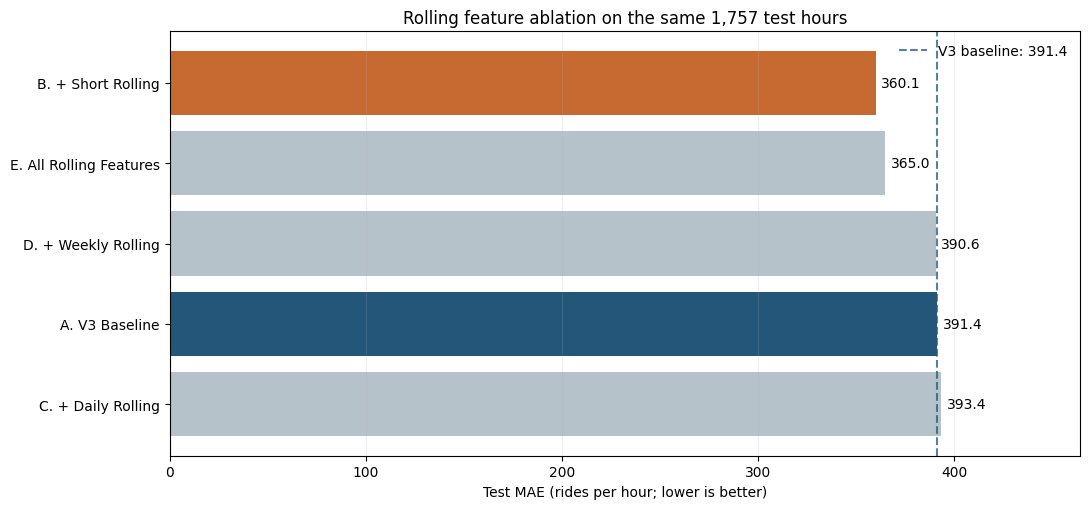

In [10]:
plot_comparison = comparison.sort_values("MAE", ascending=False)
bar_colors = [
    COLORS["V3 Baseline"] if name == baseline_name else
    COLORS["Best Rolling"] if name == best_rolling_name else "#B5C2C9"
    for name in plot_comparison["Model"]
]
fig, ax = plt.subplots(figsize=(11, 5.2))
bars = ax.barh(plot_comparison["Model"], plot_comparison["MAE"], color=bar_colors)
ax.bar_label(bars, fmt="%.1f", padding=4)
ax.axvline(baseline_mae, color=COLORS["V3 Baseline"], linestyle="--", alpha=0.75,
           label=f"V3 baseline: {baseline_mae:.1f}")
ax.set_xlim(0, plot_comparison["MAE"].max() * 1.18)
ax.set_xlabel("Test MAE (rides per hour; lower is better)")
ax.set_title("Rolling feature ablation on the same 1,757 test hours")
ax.grid(axis="x", alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 6. Rolling 特征与需求、lag 的相关性

**做什么：**只在共同**训练集**上计算六列 rolling 与 `ride_count`、三列 lag 的 Pearson 相关系数。**为什么：**可观察不同时间尺度是否提供相近信息，同时避免用测试期目标来解释训练阶段的特征选择。**输入：**6,857 个共同训练小时。**输出：**6×4 相关性表和热力图。

`rolling_mean_24` 与某些 lag **可能**相关，但强弱要看下方实际数值，不应预设它与 `lag_24` 一定高度相关。前者汇总一整天，后者只看昨天同一小时。**相关性高不等于没有增量价值**；树模型可以在不同需求水平、小时和天气条件下利用不同时间尺度。是否值得加入仍以同样本的测试误差为准。

,ride_count,lag_1,lag_24,lag_168
rolling_mean_3,0.768,0.928,0.696,0.686
rolling_mean_6,0.554,0.738,0.509,0.487
rolling_mean_24,0.396,0.407,0.410,0.333
rolling_mean_168,0.373,0.374,0.388,0.387
rolling_std_24,0.397,0.409,0.401,0.332
rolling_std_168,0.371,0.373,0.384,0.381


本数据中 `rolling_mean_3` 与 `lag_1` 的相关系数为 **0.928**；`rolling_mean_24` 与 `lag_24` 为 **0.410**。因此不能预先把所有日窗口特征都称为与 lag 高度相关。

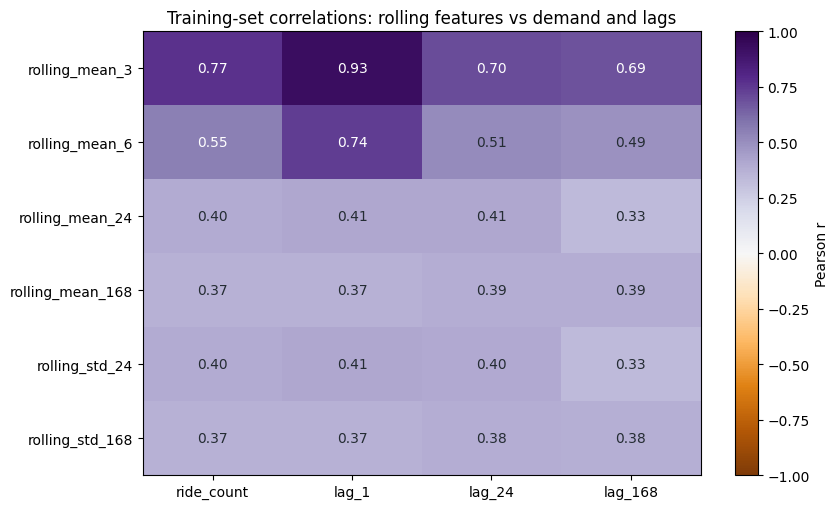

In [11]:
correlation_columns = ["ride_count"] + lag_columns + rolling_columns
correlation = train_rows[correlation_columns].corr(method="pearson")
rolling_correlation = correlation.loc[rolling_columns, ["ride_count"] + lag_columns]
display(rolling_correlation.round(3))
display(Markdown(
    f"本数据中 `rolling_mean_3` 与 `lag_1` 的相关系数为 **{rolling_correlation.loc['rolling_mean_3', 'lag_1']:.3f}**；"
    f"`rolling_mean_24` 与 `lag_24` 为 **{rolling_correlation.loc['rolling_mean_24', 'lag_24']:.3f}**。"
    "因此不能预先把所有日窗口特征都称为与 lag 高度相关。"
))

fig, ax = plt.subplots(figsize=(8.6, 5.2))
heatmap = ax.imshow(rolling_correlation, cmap="PuOr", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(rolling_correlation.shape[1]), rolling_correlation.columns)
ax.set_yticks(range(rolling_correlation.shape[0]), rolling_correlation.index)
for row in range(rolling_correlation.shape[0]):
    for col in range(rolling_correlation.shape[1]):
        value = rolling_correlation.iloc[row, col]
        ax.text(col, row, f"{value:.2f}", ha="center", va="center",
                color="white" if abs(value) > 0.55 else "#242C33")
fig.colorbar(heatmap, ax=ax, label="Pearson r")
ax.set_title("Training-set correlations: rolling features vs demand and lags")
fig.tight_layout()
plt.show()

## 7. 连续七天的预测形状

**做什么：**沿用 05 的 `2024-10-21` 至 `2024-10-27`，绘制真实值、V3 基线和最佳 rolling 方案；周末区域着灰色。**为什么：**整体 MAE 不能显示早晚通勤峰、夜间、周末及突然变化时的预测形状。**输入：**完整测试预测中连续 168 小时。**输出：**三条时间序列与局部读图依据。

这七天只用于形状诊断，最佳方案仍按全部 1,757 小时的主结果表选出。

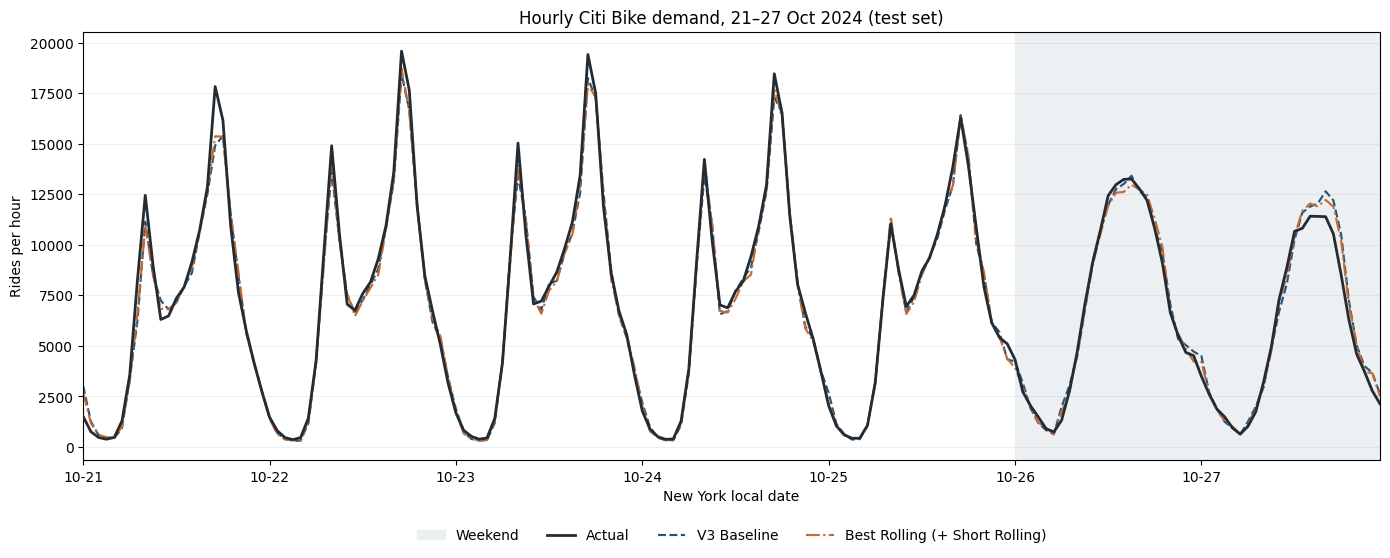

In [12]:
results = pd.DataFrame({
    "timestamp": test_rows["timestamp"].to_numpy(),
    "Actual": y_test.to_numpy(),
    "V3 Baseline": test_predictions[baseline_name],
    "Best Rolling": test_predictions[best_rolling_name],
})
results["hour"] = results["timestamp"].dt.hour
results["day_of_week"] = results["timestamp"].dt.dayofweek
week_start = pd.Timestamp("2024-10-21 00:00")
week_end = week_start + pd.Timedelta(days=7)
one_week = results.loc[
    results["timestamp"].ge(week_start) & results["timestamp"].lt(week_end)
].copy()
assert len(one_week) == 168
assert one_week["timestamp"].diff().iloc[1:].eq(pd.Timedelta(hours=1)).all()

fig, ax = plt.subplots(figsize=(14, 5.7))
ax.axvspan(pd.Timestamp("2024-10-26"), week_end, color="#E8EDF0", alpha=0.8,
           label="Weekend")
ax.plot(one_week["timestamp"], one_week["Actual"], color=COLORS["Actual"],
        linewidth=2, label="Actual", zorder=5)
ax.plot(one_week["timestamp"], one_week["V3 Baseline"],
        color=COLORS["V3 Baseline"], linestyle="--", linewidth=1.55, label="V3 Baseline")
ax.plot(one_week["timestamp"], one_week["Best Rolling"],
        color=COLORS["Best Rolling"], linestyle="-.", linewidth=1.55,
        label=f"Best Rolling ({best_rolling_name.split('. ')[1]})")
ax.set(title="Hourly Citi Bike demand, 21–27 Oct 2024 (test set)",
       xlabel="New York local date", ylabel="Rides per hour")
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.set_xlim(one_week["timestamp"].min(), one_week["timestamp"].max())
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.13))
fig.tight_layout()
plt.show()

### 7.1 量化早晚峰、夜间、周末与突变

**做什么：**分别计算这七天四种时段的 MAE、整体相邻小时变化幅度，以及实际需求跳变最大的五个小时的误差。**为什么：**帮助判断 rolling 是否让曲线更平滑，以及是否因此错过突发高峰或下降。**输入：**上图 168 小时。**输出：**局部误差、平滑度和突变诊断表。

平均相邻小时变化幅度只描述曲线有多平滑，本身不是越小越好；真实序列也可能突然变化。

In [13]:
week_patterns = {
    "Weekday morning 07–09": (one_week["day_of_week"] < 5) & one_week["hour"].isin([7, 8, 9]),
    "Weekday evening 16–19": (one_week["day_of_week"] < 5) & one_week["hour"].isin([16, 17, 18, 19]),
    "Overnight 00–05": one_week["hour"].isin(range(6)),
    "Weekend all hours": one_week["day_of_week"] >= 5,
}
week_pattern_rows = []
for pattern, mask in week_patterns.items():
    subset = one_week.loc[mask]
    for series_name in ("V3 Baseline", "Best Rolling"):
        week_pattern_rows.append({
            "Pattern": pattern, "Model": series_name, "Hours": len(subset),
            "MAE": (subset["Actual"] - subset[series_name]).abs().mean(),
        })
week_pattern_table = pd.DataFrame(week_pattern_rows).set_index(["Pattern", "Model"])
display(week_pattern_table.round(1))

smoothness = pd.DataFrame([
    {"Series": series_name,
     "Mean absolute hourly change": one_week[series_name].diff().abs().iloc[1:].mean()}
    for series_name in ("Actual", "V3 Baseline", "Best Rolling")
])
display(smoothness.round(1))

abrupt = one_week.copy()
abrupt["Actual change"] = abrupt["Actual"].diff()
abrupt["Baseline absolute error"] = (abrupt["Actual"] - abrupt["V3 Baseline"]).abs()
abrupt["Rolling absolute error"] = (abrupt["Actual"] - abrupt["Best Rolling"]).abs()
abrupt["Absolute change"] = abrupt["Actual change"].abs()
largest_changes = abrupt.iloc[1:].nlargest(5, "Absolute change")[[
    "timestamp", "Actual change", "Baseline absolute error", "Rolling absolute error"
]]
largest_changes_preview = largest_changes.copy()
numeric_columns = ["Actual change", "Baseline absolute error", "Rolling absolute error"]
largest_changes_preview[numeric_columns] = largest_changes_preview[numeric_columns].round(1)
display(largest_changes_preview)

Hours    MAE
Pattern               Model                     
Weekday morning 07–09 V3 Baseline      15  678.8
                      Best Rolling     15  632.4
Weekday evening 16–19 V3 Baseline      20  704.7
                      Best Rolling     20  632.3
Overnight 00–05       V3 Baseline      42  199.3
                      Best Rolling     42  153.0
Weekend all hours     V3 Baseline      48  407.5
                      Best Rolling     48  356.5

,Series,Mean absolute hourly change
0,Actual,1752.3
1,V3 Baseline,1655.4
2,Best Rolling,1672.6


,timestamp,Actual change,Baseline absolute error,Rolling absolute error
71,2024-10-22 17:00:00,5986.0,1121.7,857.0
95,2024-10-23 17:00:00,5978.0,1164.8,1473.1
73,2024-10-22 19:00:00,-5698.0,3.0,198.1
86,2024-10-23 08:00:00,5632.0,1623.3,1075.9
97,2024-10-23 19:00:00,-5604.0,716.2,468.5


## 8. 全测试集工作日通勤高峰

**做什么：**对所有测试期工作日的 07–09 点和 16–19 点，比较 V3 基线与最佳 rolling 方案的 Mean Error、MAE。**为什么：**整体改善可能掩盖高需求时段退步。**输入：**同一测试期真实值和两组预测。**输出：**各高峰的小时数、偏差方向和误差。

`Mean Error = Actual − Prediction`：正值表示平均低估，负值表示平均高估；MAE 则不让正负误差互相抵消。

In [14]:
weekday_results = results.loc[results["day_of_week"] < 5]
peak_periods = {"Morning 07–09": [7, 8, 9], "Evening 16–19": [16, 17, 18, 19]}
peak_rows = []
for period, hours in peak_periods.items():
    subset = weekday_results.loc[weekday_results["hour"].isin(hours)]
    for model_name in ("V3 Baseline", "Best Rolling"):
        error = subset["Actual"] - subset[model_name]
        peak_rows.append({
            "Period": period, "Model": model_name, "Hours": len(subset),
            "Mean Error": error.mean(), "MAE": error.abs().mean(),
        })
peak_comparison = pd.DataFrame(peak_rows).set_index(["Period", "Model"])
assert peak_comparison.loc[("Morning 07–09", "V3 Baseline"), "Hours"] == 156
assert peak_comparison.loc[("Evening 16–19", "V3 Baseline"), "Hours"] == 208
display(peak_comparison.round(1))

Hours  Mean Error    MAE
Period        Model                                 
Morning 07–09 V3 Baseline     156         0.6  597.4
              Best Rolling    156        52.3  574.6
Evening 16–19 V3 Baseline     208      -141.8  776.4
              Best Rolling    208       -94.8  732.3

## 9. 最佳 Rolling 模型的残差结构

**做什么：**令 `residual = actual − prediction`，计算总体均值、MAE、标准差；再按月份、是否通勤高峰和日期查看误差。**为什么：**总体 MAE 可能隐藏持续偏高／偏低、尖峰误差和异常日期。**输入：**最佳 rolling 模型的 1,757 个测试预测。**输出：**残差统计、月度偏差、分时段误差和误差最大的日期。

这里的“异常日期”只是按本测试期的日均绝对误差排序，不解释具体外部原因。10 月只包含 19 日晚至月底；月间比较应注意覆盖时长不同。

In [15]:
results["Residual"] = results["Actual"] - results["Best Rolling"]
residual_stats = pd.DataFrame([{
    "Residual Mean": results["Residual"].mean(),
    "Residual MAE": results["Residual"].abs().mean(),
    "Residual Std": results["Residual"].std(ddof=1),
}])
assert np.isclose(residual_stats["Residual MAE"].iloc[0], best_rolling_row["MAE"])
display(residual_stats.round(2))

results["month"] = results["timestamp"].dt.to_period("M").astype(str)
monthly_residuals = results.groupby("month").agg(
    Hours=("Residual", "size"),
    Mean_Error=("Residual", "mean"),
    MAE=("Residual", lambda series: series.abs().mean()),
    Residual_Std=("Residual", "std"),
)
display(monthly_residuals.round(1))

commute_peak = (results["day_of_week"] < 5) & (
    results["hour"].isin([7, 8, 9, 16, 17, 18, 19])
)
residual_by_period = pd.DataFrame([
    {"Period": period, "Hours": int(mask.sum()),
     "Mean Error": results.loc[mask, "Residual"].mean(),
     "MAE": results.loc[mask, "Residual"].abs().mean()}
    for period, mask in (("Weekday commute peaks", commute_peak),
                         ("Other hours", ~commute_peak))
])
display(residual_by_period.round(1))

results["date"] = results["timestamp"].dt.date
daily_residuals = results.groupby("date").agg(
    Hours=("Residual", "size"),
    Mean_Error=("Residual", "mean"),
    MAE=("Residual", lambda series: series.abs().mean()),
)
worst_days = daily_residuals.nlargest(5, "MAE")
display(worst_days.round(1))

,Residual Mean,Residual MAE,Residual Std
0,-23.42,360.09,585.76


,Hours,Mean_Error,MAE,Residual_Std
month,,,,
2024-10,294,93.5,348.4,498.9
2024-11,719,-95.1,395.1,653.9
2024-12,744,-0.3,330.9,537.2


,Period,Hours,Mean Error,MAE
0,Weekday commute peaks,364,-31.8,664.7
1,Other hours,1393,-21.2,280.5


,Hours,Mean_Error,MAE
date,,,
2024-11-14,24,-60.5,759.4
2024-11-26,24,-436.6,687.7
2024-12-18,24,-109.4,612.8
2024-11-21,24,-335.6,583.7
2024-11-27,24,-249.5,565.8


### 9.1 Residual vs Time

**做什么：**将每个测试小时的残差按时间画出，同时叠加仅用于观察的过去 24 小时平均残差。**为什么：**零线附近的随机起伏与持续同号的偏差，在时间图上更容易区分。**输入：**最佳 rolling 模型的测试残差。**输出：**残差时间图。

图上的 24 小时曲线是**诊断时的平滑展示**，不是新的模型输入，也不参与预测评估。

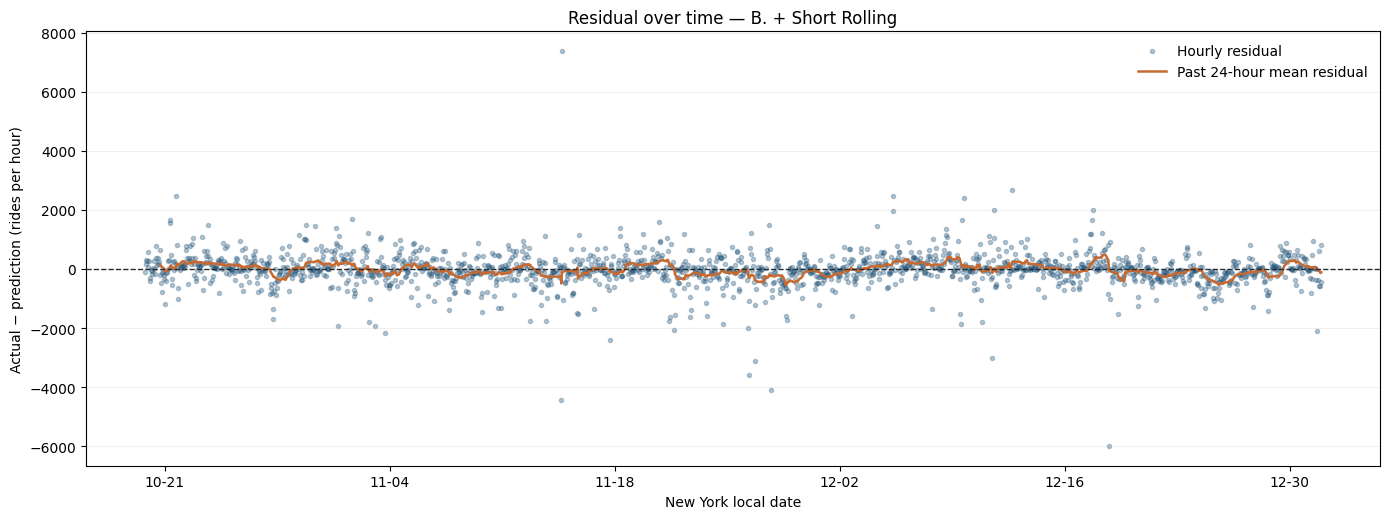

In [16]:
residual_24h_mean = results["Residual"].rolling(window=24, min_periods=24).mean()
fig, ax = plt.subplots(figsize=(14, 5.3))
ax.scatter(results["timestamp"], results["Residual"], s=9, alpha=0.32,
           color="#24567A", label="Hourly residual")
ax.plot(results["timestamp"], residual_24h_mean, color="#C66A32",
        linewidth=1.8, label="Past 24-hour mean residual")
ax.axhline(0, color="#242C33", linewidth=1, linestyle="--")
ax.set(title=f"Residual over time — {best_rolling_name}",
       xlabel="New York local date", ylabel="Actual − prediction (rides per hour)")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 10. Train / Test Gap

**做什么：**对 V3 基线和最佳 rolling 方案计算训练 MAE、测试 MAE 和 `Generalization Gap = Test MAE − Train MAE`。**为什么：**训练误差下降不足以证明未来预测改善。**输入：**同一共同训练行、同一测试行与两组预测。**输出：**泛化差距表。

正差距可能来自拟合过度，也可能有 10–12 月的季节分布变化；单次时间切分不能单独证明原因。判断是否值得保留 rolling，优先看同测试集 MAE 和高峰表现。

In [17]:
gap_rows = []
for model_name in (baseline_name, best_rolling_name):
    train_mae = mean_absolute_error(y_train, train_predictions[model_name])
    test_mae = mean_absolute_error(y_test, test_predictions[model_name])
    gap_rows.append({
        "Model": model_name,
        "Train MAE": train_mae,
        "Test MAE": test_mae,
        "Generalization Gap": test_mae - train_mae,
    })
generalization_gap = pd.DataFrame(gap_rows).set_index("Model")
assert abs(generalization_gap.loc[baseline_name, "Train MAE"] - 246.16) < 0.05
display(generalization_gap.round(2))

,Train MAE,Test MAE,Generalization Gap
Model,,,
A. V3 Baseline,246.16,391.42,145.27
B. + Short Rolling,220.80,360.09,139.29


## 11. 实验总结与预测限制

**做什么：**从已经计算的表格自动生成十项结论。**为什么：**避免手写数字与重新运行后的结果不一致。**输入：**消融指标、七天局部诊断、高峰、残差和泛化差距。**输出：**值得保留的 rolling 方案及下一步方向。

**预测限制：**本实验依赖每个预测时刻之前的真实需求。例如测试期内某小时的 `lag_1` 和 `rolling_mean_24` 会使用测试期更早小时的真实值，因此这是 **one-step-ahead forecasting**。这些 MAE 不能直接表示在某个起点**一次性预测未来完整 7 天**的能力；那时未来区间内部的真实 `lag_1` 和 rolling 均尚不可得，需要递归预测、直接多步预测等策略并重新评估。05/06 的同小时观测天气也需要换成预测当时可取得的天气信息。

In [18]:
by_model = comparison.set_index("Model")
single_group_names = ["B. + Short Rolling", "C. + Daily Rolling", "D. + Weekly Rolling"]
best_single_group = by_model.loc[single_group_names, "MAE"].idxmin()
baseline_gap = generalization_gap.loc[baseline_name]
rolling_gap = generalization_gap.loc[best_rolling_name]

morning_base = peak_comparison.loc[("Morning 07–09", "V3 Baseline")]
morning_roll = peak_comparison.loc[("Morning 07–09", "Best Rolling")]
evening_base = peak_comparison.loc[("Evening 16–19", "V3 Baseline")]
evening_roll = peak_comparison.loc[("Evening 16–19", "Best Rolling")]
peak_direction = lambda before, after: "改善" if after < before else "变差" if after > before else "持平"

rolling_gain = baseline_mae - best_rolling_row["MAE"]
rolling_gain_pct = rolling_gain / baseline_mae * 100
gap_change = rolling_gap["Generalization Gap"] - baseline_gap["Generalization Gap"]
keep_rolling = rolling_gain > 0

week_actual_change = smoothness.set_index("Series").loc["Actual", "Mean absolute hourly change"]
week_base_change = smoothness.set_index("Series").loc["V3 Baseline", "Mean absolute hourly change"]
week_roll_change = smoothness.set_index("Series").loc["Best Rolling", "Mean absolute hourly change"]
abrupt_baseline_mae = largest_changes["Baseline absolute error"].mean()
abrupt_rolling_mae = largest_changes["Rolling absolute error"].mean()
abrupt_worse_count = int((largest_changes["Rolling absolute error"] > largest_changes["Baseline absolute error"]).sum())
week_night_base = week_pattern_table.loc[("Overnight 00–05", "V3 Baseline"), "MAE"]
week_night_roll = week_pattern_table.loc[("Overnight 00–05", "Best Rolling"), "MAE"]
week_weekend_base = week_pattern_table.loc[("Weekend all hours", "V3 Baseline"), "MAE"]
week_weekend_roll = week_pattern_table.loc[("Weekend all hours", "Best Rolling"), "MAE"]

monthly_bias_min = monthly_residuals["Mean_Error"].min()
monthly_bias_max = monthly_residuals["Mean_Error"].max()
most_overestimated_month = monthly_residuals["Mean_Error"].idxmin()
most_underestimated_month = monthly_residuals["Mean_Error"].idxmax()
peak_residual_mae = residual_by_period.set_index("Period").loc["Weekday commute peaks", "MAE"]
other_residual_mae = residual_by_period.set_index("Period").loc["Other hours", "MAE"]

summary_lines = [
    f"1. **最佳 Rolling 组合：**{best_rolling_name}（新增 `{added_features[best_rolling_name]}`）；测试 MAE **{best_rolling_row['MAE']:.2f}**、RMSE **{best_rolling_row['RMSE']:.2f}**、R² **{best_rolling_row['R²']:.3f}**，负预测 **{int(best_rolling_row['Negative Predictions'])}** 个。",
    f"2. **相对 V3 与 05 基线：**同样本基线 MAE **{baseline_mae:.2f}**、RMSE **{baseline_row['RMSE']:.2f}**、R² **{baseline_row['R²']:.3f}**，与 05 报告的 HistGradientBoosting 指标一致；最佳 Rolling 的 MAE {'降低' if rolling_gain >= 0 else '增加'} **{abs(rolling_gain):.2f}** 次/小时（{'改善' if rolling_gain_pct >= 0 else '变差'} **{abs(rolling_gain_pct):.2f}%**）。",
    f"3. **哪类窗口最有效：**单独加一类时，**{best_single_group}** 的测试 MAE 最低（{by_model.loc[best_single_group, 'MAE']:.2f}）；Short / Daily / Weekly 的完整数值见第 5.1 节。全部一起加入未必优于最好的单类。",
    f"4. **七天形状：**真实 / 基线 / Rolling 的平均相邻小时变化幅度为 **{week_actual_change:.1f} / {week_base_change:.1f} / {week_roll_change:.1f}**；Rolling {'比基线更平滑' if week_roll_change < week_base_change else '并未比基线更平滑'}。本周夜间 MAE **{week_night_base:.1f} → {week_night_roll:.1f}**、周末 **{week_weekend_base:.1f} → {week_weekend_roll:.1f}**。真实需求跳变最大的五个小时，基线 / Rolling 平均绝对误差为 **{abrupt_baseline_mae:.1f} / {abrupt_rolling_mae:.1f}**，但 Rolling 在其中 **{abrupt_worse_count}/5** 个小时更差。",
    f"5. **工作日早高峰：**基线 / Rolling MAE **{morning_base['MAE']:.1f} / {morning_roll['MAE']:.1f}**，{peak_direction(morning_base['MAE'], morning_roll['MAE'])}；Mean Error **{morning_base['Mean Error']:+.1f} / {morning_roll['Mean Error']:+.1f}**（正数为低估）。",
    f"6. **工作日晚高峰：**基线 / Rolling MAE **{evening_base['MAE']:.1f} / {evening_roll['MAE']:.1f}**，{peak_direction(evening_base['MAE'], evening_roll['MAE'])}；Mean Error **{evening_base['Mean Error']:+.1f} / {evening_roll['Mean Error']:+.1f}**。",
    f"7. **泛化与过拟合：**基线 Train/Test MAE **{baseline_gap['Train MAE']:.2f} / {baseline_gap['Test MAE']:.2f}**（差距 {baseline_gap['Generalization Gap']:.2f}）；Rolling **{rolling_gap['Train MAE']:.2f} / {rolling_gap['Test MAE']:.2f}**（差距 {rolling_gap['Generalization Gap']:.2f}，变化 {gap_change:+.2f}）。训练和测试误差均下降，未见新增的明显过拟合；差距仍在，单次时间切分无法把过拟合与季节变化分开。",
    f"8. **残差：**Mean **{residual_stats['Residual Mean'].iloc[0]:+.2f}**、MAE **{residual_stats['Residual MAE'].iloc[0]:.2f}**、Std **{residual_stats['Residual Std'].iloc[0]:.2f}**；月均误差在 **{monthly_bias_min:+.1f} 至 {monthly_bias_max:+.1f}**，**{most_overestimated_month}** 最偏向高估、**{most_underestimated_month}** 最偏向低估。工作日通勤高峰 / 其他小时残差 MAE **{peak_residual_mae:.1f} / {other_residual_mae:.1f}**；残差仍有时间结构，具体日期见第 9 节。",
    f"9. **是否保留 Rolling：**{'本次相同测试期的 MAE 有改善，值得作为候选保留；还需在未来独立时段验证。' if keep_rolling else '本次相同测试期未改善 MAE，暂不建议仅因训练误差而保留；可在未来独立时段复核。'}",
    "10. **下一步：**若任务是提前一次性预测未来 7 天，应进入 Multi-Step Forecasting，重新设计不可直接获得的未来 lag / rolling，并使用当时可用的天气预报；当前数字仅代表逐小时 one-step-ahead 设定。",
]
display(Markdown("\n\n".join(summary_lines)))

1. **最佳 Rolling 组合：**B. + Short Rolling（新增 `rolling_mean_3, rolling_mean_6`）；测试 MAE **360.09**、RMSE **586.06**、R² **0.977**，负预测 **0** 个。

2. **相对 V3 与 05 基线：**同样本基线 MAE **391.42**、RMSE **626.17**、R² **0.974**，与 05 报告的 HistGradientBoosting 指标一致；最佳 Rolling 的 MAE 降低 **31.33** 次/小时（改善 **8.01%**）。

3. **哪类窗口最有效：**单独加一类时，**B. + Short Rolling** 的测试 MAE 最低（360.09）；Short / Daily / Weekly 的完整数值见第 5.1 节。全部一起加入未必优于最好的单类。

4. **七天形状：**真实 / 基线 / Rolling 的平均相邻小时变化幅度为 **1752.3 / 1655.4 / 1672.6**；Rolling 并未比基线更平滑。本周夜间 MAE **199.3 → 153.0**、周末 **407.5 → 356.5**。真实需求跳变最大的五个小时，基线 / Rolling 平均绝对误差为 **925.8 / 814.5**，但 Rolling 在其中 **2/5** 个小时更差。

5. **工作日早高峰：**基线 / Rolling MAE **597.4 / 574.6**，改善；Mean Error **+0.6 / +52.3**（正数为低估）。

6. **工作日晚高峰：**基线 / Rolling MAE **776.4 / 732.3**，改善；Mean Error **-141.8 / -94.8**。

7. **泛化与过拟合：**基线 Train/Test MAE **246.16 / 391.42**（差距 145.27）；Rolling **220.80 / 360.09**（差距 139.29，变化 -5.98）。训练和测试误差均下降，未见新增的明显过拟合；差距仍在，单次时间切分无法把过拟合与季节变化分开。

8. **残差：**Mean **-23.42**、MAE **360.09**、Std **585.76**；月均误差在 **-95.1 至 +93.5**，**2024-11** 最偏向高估、**2024-10** 最偏向低估。工作日通勤高峰 / 其他小时残差 MAE **664.7 / 280.5**；残差仍有时间结构，具体日期见第 9 节。

9. **是否保留 Rolling：**本次相同测试期的 MAE 有改善，值得作为候选保留；还需在未来独立时段验证。

10. **下一步：**若任务是提前一次性预测未来 7 天，应进入 Multi-Step Forecasting，重新设计不可直接获得的未来 lag / rolling，并使用当时可用的天气预报；当前数字仅代表逐小时 one-step-ahead 设定。